In [1]:
!pip install gymnasium[classic-control] torch matplotlib pandas numpy

Defaulting to user installation because normal site-packages is not writeable


Using device: cpu

Environment: CartPole-v1
State size : 4
Action size: 2

State variables:
1. Cart position
2. Cart velocity
3. Pole angle
4. Pole angular velocity

Actions:
0 = Move Left
1 = Move Right


STARTING DQN TRAINING
Episode:   1 | Reward:   29.0 | Avg(20):   29.0 | Epsilon: 0.995
Episode:  10 | Reward:   16.0 | Avg(20):   24.5 | Epsilon: 0.951
Episode:  20 | Reward:   29.0 | Avg(20):   25.9 | Epsilon: 0.905
Episode:  30 | Reward:   24.0 | Avg(20):   25.4 | Epsilon: 0.860
Episode:  40 | Reward:   17.0 | Avg(20):   23.0 | Epsilon: 0.818
Episode:  50 | Reward:   22.0 | Avg(20):   20.6 | Epsilon: 0.778
Episode:  60 | Reward:   26.0 | Avg(20):   23.1 | Epsilon: 0.740
Episode:  70 | Reward:   46.0 | Avg(20):   30.4 | Epsilon: 0.704
Episode:  80 | Reward:   16.0 | Avg(20):   30.9 | Epsilon: 0.670
Episode:  90 | Reward:   34.0 | Avg(20):   30.9 | Epsilon: 0.637
Episode: 100 | Reward:   11.0 | Avg(20):   31.8 | Epsilon: 0.606
Episode: 110 | Reward:   21.0 | Avg(20):   35.0 | Epsilon

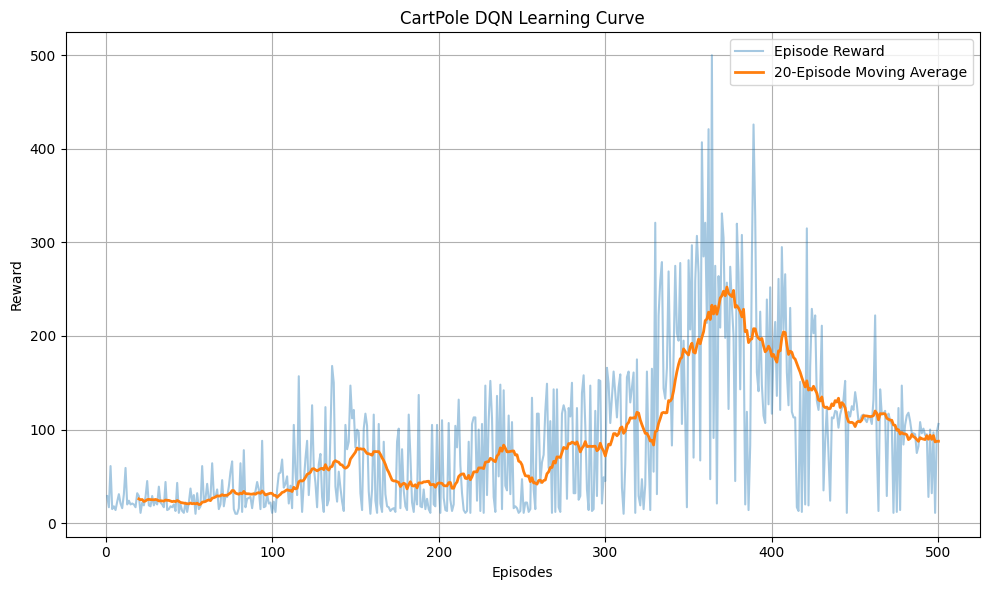


Learning curve saved as: cartpole_dqn_learning_curve.png


TRAINING PERFORMANCE
Number of episodes       : 500
Average training reward  : 87.64
Last 20 episode average  : 87.55
Maximum reward           : 500.00
Minimum reward           : 10.00


EVALUATING TRAINED AGENT
Evaluation Episode  1: Reward = 95.0
Evaluation Episode  2: Reward = 96.0
Evaluation Episode  3: Reward = 95.0
Evaluation Episode  4: Reward = 92.0
Evaluation Episode  5: Reward = 89.0
Evaluation Episode  6: Reward = 99.0
Evaluation Episode  7: Reward = 91.0
Evaluation Episode  8: Reward = 77.0
Evaluation Episode  9: Reward = 92.0
Evaluation Episode 10: Reward = 101.0
Evaluation Episode 11: Reward = 93.0
Evaluation Episode 12: Reward = 96.0
Evaluation Episode 13: Reward = 91.0
Evaluation Episode 14: Reward = 91.0
Evaluation Episode 15: Reward = 90.0
Evaluation Episode 16: Reward = 78.0
Evaluation Episode 17: Reward = 95.0
Evaluation Episode 18: Reward = 91.0
Evaluation Episode 19: Reward = 90.0
Evaluation Episode 20: R

C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Final demonstration reward: 96.0


LAB 5 EXECUTION COMPLETED

Generated files:
1. cartpole_dqn_model.pth
2. cartpole_dqn_rewards.csv
3. cartpole_dqn_learning_curve.png
4. cartpole_dqn_evaluation.txt

Use the learning curve and final demonstration
screenshots in your Lab-5 report.


In [2]:
# ============================================================
# LAB ASSIGNMENT 5
# CartPole Balancing using Deep Q-Network (DQN)
# ============================================================

import os
import random
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym

import torch
import torch.nn as nn
import torch.optim as optim


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 42

NUM_EPISODES = 500

GAMMA = 0.99

LEARNING_RATE = 0.001

BATCH_SIZE = 64

MEMORY_SIZE = 50000

MIN_MEMORY_SIZE = 1000

EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.995

TARGET_UPDATE_FREQUENCY = 10

HIDDEN_SIZE = 128

MODEL_FILE = "cartpole_dqn_model.pth"

REWARD_CSV = "cartpole_dqn_rewards.csv"

LEARNING_CURVE_FILE = "cartpole_dqn_learning_curve.png"

EVALUATION_FILE = "cartpole_dqn_evaluation.txt"

FINAL_SCREENSHOT = "cartpole_dqn_final.png"


# ============================================================
# 2. RANDOM SEED
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


# ============================================================
# 3. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ============================================================
# 4. CREATE ENVIRONMENT
# ============================================================

env = gym.make("CartPole-v1")

env.reset(seed=SEED)
env.action_space.seed(SEED)


state_size = env.observation_space.shape[0]

action_size = env.action_space.n

print("\nEnvironment:", "CartPole-v1")
print("State size :", state_size)
print("Action size:", action_size)

print("\nState variables:")
print("1. Cart position")
print("2. Cart velocity")
print("3. Pole angle")
print("4. Pole angular velocity")

print("\nActions:")
print("0 = Move Left")
print("1 = Move Right")


# ============================================================
# 5. REPLAY BUFFER
# ============================================================

class ReplayBuffer:

    def __init__(self, capacity):

        self.memory = deque(maxlen=capacity)


    def store(self, state, action, reward, next_state, done):

        self.memory.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )


    def sample(self, batch_size):

        batch = random.sample(
            self.memory,
            batch_size
        )

        states, actions, rewards, next_states, dones = zip(*batch)

        return (
            np.array(states, dtype=np.float32),
            np.array(actions, dtype=np.int64),
            np.array(rewards, dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones, dtype=np.float32)
        )


    def __len__(self):

        return len(self.memory)


# ============================================================
# 6. DQN NEURAL NETWORK
# ============================================================

class DQN(nn.Module):

    def __init__(self, state_size, action_size):

        super(DQN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(state_size, HIDDEN_SIZE),

            nn.ReLU(),

            nn.Linear(HIDDEN_SIZE, HIDDEN_SIZE),

            nn.ReLU(),

            nn.Linear(HIDDEN_SIZE, action_size)
        )


    def forward(self, state):

        return self.network(state)


# ============================================================
# 7. CREATE POLICY AND TARGET NETWORK
# ============================================================

policy_network = DQN(
    state_size,
    action_size
).to(device)


target_network = DQN(
    state_size,
    action_size
).to(device)


# Initially both networks have the same weights

target_network.load_state_dict(
    policy_network.state_dict()
)

target_network.eval()


# ============================================================
# 8. OPTIMIZER
# ============================================================

optimizer = optim.Adam(
    policy_network.parameters(),
    lr=LEARNING_RATE
)


# ============================================================
# 9. LOSS FUNCTION
# ============================================================

loss_function = nn.SmoothL1Loss()


# ============================================================
# 10. REPLAY MEMORY
# ============================================================

memory = ReplayBuffer(
    MEMORY_SIZE
)


# ============================================================
# 11. EPSILON-GREEDY ACTION SELECTION
# ============================================================

def select_action(state, epsilon):

    # Exploration

    if random.random() < epsilon:

        return env.action_space.sample()


    # Exploitation

    state_tensor = torch.tensor(
        state,
        dtype=torch.float32
    ).unsqueeze(0).to(device)


    with torch.no_grad():

        q_values = policy_network(
            state_tensor
        )


    action = q_values.argmax(
        dim=1
    ).item()


    return action


# ============================================================
# 12. TRAIN DQN
# ============================================================

def train_dqn():

    if len(memory) < MIN_MEMORY_SIZE:

        return None


    # Sample random mini-batch

    states, actions, rewards, next_states, dones = \
        memory.sample(BATCH_SIZE)


    states = torch.tensor(
        states,
        dtype=torch.float32
    ).to(device)


    actions = torch.tensor(
        actions,
        dtype=torch.long
    ).to(device)


    rewards = torch.tensor(
        rewards,
        dtype=torch.float32
    ).to(device)


    next_states = torch.tensor(
        next_states,
        dtype=torch.float32
    ).to(device)


    dones = torch.tensor(
        dones,
        dtype=torch.float32
    ).to(device)


    # --------------------------------------------------------
    # Current Q-values
    # --------------------------------------------------------

    current_q_values = policy_network(
        states
    ).gather(
        1,
        actions.unsqueeze(1)
    ).squeeze(1)


    # --------------------------------------------------------
    # Next Q-values
    # --------------------------------------------------------

    with torch.no_grad():

        next_q_values = target_network(
            next_states
        ).max(
            dim=1
        )[0]


    # --------------------------------------------------------
    # DQN target
    #
    # y = r + gamma * max Q(next_state, action)
    # --------------------------------------------------------

    target_q_values = rewards + (
        GAMMA * next_q_values * (1 - dones)
    )


    # --------------------------------------------------------
    # Calculate loss
    # --------------------------------------------------------

    loss = loss_function(
        current_q_values,
        target_q_values
    )


    # --------------------------------------------------------
    # Backpropagation
    # --------------------------------------------------------

    optimizer.zero_grad()

    loss.backward()

    # Gradient clipping for stability

    torch.nn.utils.clip_grad_norm_(
        policy_network.parameters(),
        max_norm=1.0
    )

    optimizer.step()


    return loss.item()


# ============================================================
# 13. TRAINING
# ============================================================

episode_rewards = []

episode_losses = []

epsilon_values = []

epsilon = EPSILON_START


print("\n")
print("=" * 60)
print("STARTING DQN TRAINING")
print("=" * 60)


for episode in range(1, NUM_EPISODES + 1):

    state, info = env.reset()

    total_reward = 0

    losses = []


    # --------------------------------------------------------
    # Episode loop
    # --------------------------------------------------------

    while True:

        # Choose action

        action = select_action(
            state,
            epsilon
        )


        # Take action

        next_state, reward, terminated, truncated, info = \
            env.step(action)


        done = terminated or truncated


        # Store experience

        memory.store(
            state,
            action,
            reward,
            next_state,
            done
        )


        # Train the network

        loss = train_dqn()


        if loss is not None:

            losses.append(loss)


        # Move to next state

        state = next_state

        total_reward += reward


        if done:

            break


    # --------------------------------------------------------
    # Store results
    # --------------------------------------------------------

    episode_rewards.append(
        total_reward
    )


    if len(losses) > 0:

        episode_losses.append(
            np.mean(losses)
        )

    else:

        episode_losses.append(
            0
        )


    epsilon_values.append(
        epsilon
    )


    # --------------------------------------------------------
    # Reduce epsilon
    # --------------------------------------------------------

    epsilon = max(
        EPSILON_MIN,
        epsilon * EPSILON_DECAY
    )


    # --------------------------------------------------------
    # Update target network
    # --------------------------------------------------------

    if episode % TARGET_UPDATE_FREQUENCY == 0:

        target_network.load_state_dict(
            policy_network.state_dict()
        )


    # --------------------------------------------------------
    # Moving average
    # --------------------------------------------------------

    if len(episode_rewards) >= 20:

        average_reward = np.mean(
            episode_rewards[-20:]
        )

    else:

        average_reward = np.mean(
            episode_rewards
        )


    # --------------------------------------------------------
    # Print training information
    # --------------------------------------------------------

    if episode % 10 == 0 or episode == 1:

        print(
            f"Episode: {episode:3d} | "
            f"Reward: {total_reward:6.1f} | "
            f"Avg(20): {average_reward:6.1f} | "
            f"Epsilon: {epsilon:.3f}"
        )


# ============================================================
# 14. SAVE TRAINED MODEL
# ============================================================

torch.save(
    policy_network.state_dict(),
    MODEL_FILE
)

print("\nModel saved as:", MODEL_FILE)


# ============================================================
# 15. SAVE TRAINING RESULTS
# ============================================================

results_df = pd.DataFrame({

    "Episode":
        range(1, NUM_EPISODES + 1),

    "Reward":
        episode_rewards,

    "Loss":
        episode_losses,

    "Epsilon":
        epsilon_values

})


results_df.to_csv(
    REWARD_CSV,
    index=False
)


print(
    "Training results saved as:",
    REWARD_CSV
)


# ============================================================
# 16. LEARNING CURVE
# ============================================================

episodes = np.arange(
    1,
    NUM_EPISODES + 1
)


# Calculate moving average

window = 20

moving_average = pd.Series(
    episode_rewards
).rolling(
    window
).mean()


plt.figure(
    figsize=(10, 6)
)

plt.plot(
    episodes,
    episode_rewards,
    alpha=0.4,
    label="Episode Reward"
)

plt.plot(
    episodes,
    moving_average,
    linewidth=2,
    label="20-Episode Moving Average"
)

plt.xlabel(
    "Episodes"
)

plt.ylabel(
    "Reward"
)

plt.title(
    "CartPole DQN Learning Curve"
)

plt.legend()

plt.grid(
    True
)

plt.tight_layout()


plt.savefig(
    LEARNING_CURVE_FILE,
    dpi=300
)

plt.show()


print(
    "\nLearning curve saved as:",
    LEARNING_CURVE_FILE
)


# ============================================================
# 17. TRAINING PERFORMANCE
# ============================================================

average_reward = np.mean(
    episode_rewards
)

last_20_average = np.mean(
    episode_rewards[-20:]
)

maximum_reward = np.max(
    episode_rewards
)

minimum_reward = np.min(
    episode_rewards
)


print("\n")
print("=" * 60)
print("TRAINING PERFORMANCE")
print("=" * 60)

print(
    f"Number of episodes       : {NUM_EPISODES}"
)

print(
    f"Average training reward  : {average_reward:.2f}"
)

print(
    f"Last 20 episode average  : {last_20_average:.2f}"
)

print(
    f"Maximum reward           : {maximum_reward:.2f}"
)

print(
    f"Minimum reward           : {minimum_reward:.2f}"
)


# ============================================================
# 18. EVALUATION FUNCTION
# ============================================================

def evaluate_agent(
    num_episodes=20,
    render=False
):

    evaluation_env = gym.make(
        "CartPole-v1",
        render_mode="human" if render else None
    )


    evaluation_rewards = []


    for episode in range(
        1,
        num_episodes + 1
    ):

        state, info = evaluation_env.reset()

        total_reward = 0


        while True:

            # No exploration during evaluation

            state_tensor = torch.tensor(
                state,
                dtype=torch.float32
            ).unsqueeze(0).to(device)


            with torch.no_grad():

                q_values = policy_network(
                    state_tensor
                )


            action = q_values.argmax(
                dim=1
            ).item()


            next_state, reward, terminated, truncated, info = \
                evaluation_env.step(action)


            total_reward += reward

            state = next_state


            if terminated or truncated:

                break


        evaluation_rewards.append(
            total_reward
        )


        print(
            f"Evaluation Episode "
            f"{episode:2d}: "
            f"Reward = {total_reward:.1f}"
        )


    evaluation_env.close()


    return evaluation_rewards


# ============================================================
# 19. RUN EVALUATION
# ============================================================

print("\n")
print("=" * 60)
print("EVALUATING TRAINED AGENT")
print("=" * 60)


evaluation_rewards = evaluate_agent(
    num_episodes=20,
    render=False
)


# ============================================================
# 20. EVALUATION PERFORMANCE
# ============================================================

evaluation_average = np.mean(
    evaluation_rewards
)

evaluation_max = np.max(
    evaluation_rewards
)

evaluation_min = np.min(
    evaluation_rewards
)


# We define an evaluation episode as successful
# if reward >= 195.

SUCCESS_THRESHOLD = 195

successful_episodes = sum(
    reward >= SUCCESS_THRESHOLD
    for reward in evaluation_rewards
)


success_rate = (
    successful_episodes
    / len(evaluation_rewards)
) * 100


print("\n")
print("=" * 60)
print("FINAL AGENT PERFORMANCE")
print("=" * 60)

print(
    f"Evaluation episodes       : "
    f"{len(evaluation_rewards)}"
)

print(
    f"Average evaluation reward : "
    f"{evaluation_average:.2f}"
)

print(
    f"Maximum evaluation reward : "
    f"{evaluation_max:.2f}"
)

print(
    f"Minimum evaluation reward : "
    f"{evaluation_min:.2f}"
)

print(
    f"Successful episodes       : "
    f"{successful_episodes}/{len(evaluation_rewards)}"
)

print(
    f"Success rate              : "
    f"{success_rate:.2f}%"
)

print(
    f"Success threshold         : "
    f"{SUCCESS_THRESHOLD}"
)


# ============================================================
# 21. SAVE EVALUATION RESULTS
# ============================================================

with open(
    EVALUATION_FILE,
    "w"
) as file:

    file.write(
        "CartPole DQN Evaluation Results\n"
    )

    file.write(
        "================================\n\n"
    )

    file.write(
        f"Training episodes: "
        f"{NUM_EPISODES}\n"
    )

    file.write(
        f"Average training reward: "
        f"{average_reward:.2f}\n"
    )

    file.write(
        f"Last 20 episode average: "
        f"{last_20_average:.2f}\n"
    )

    file.write(
        f"Maximum training reward: "
        f"{maximum_reward:.2f}\n\n"
    )

    file.write(
        f"Evaluation episodes: "
        f"{len(evaluation_rewards)}\n"
    )

    file.write(
        f"Average evaluation reward: "
        f"{evaluation_average:.2f}\n"
    )

    file.write(
        f"Maximum evaluation reward: "
        f"{evaluation_max:.2f}\n"
    )

    file.write(
        f"Minimum evaluation reward: "
        f"{evaluation_min:.2f}\n"
    )

    file.write(
        f"Successful episodes: "
        f"{successful_episodes}\n"
    )

    file.write(
        f"Success rate: "
        f"{success_rate:.2f}%\n\n"
    )

    file.write(
        "Individual evaluation rewards:\n"
    )

    for i, reward in enumerate(
        evaluation_rewards,
        start=1
    ):

        file.write(
            f"Episode {i}: "
            f"{reward:.1f}\n"
        )


print(
    "\nEvaluation results saved as:",
    EVALUATION_FILE
)


# ============================================================
# 22. FINAL VISUAL DEMONSTRATION
# ============================================================

print("\n")
print("=" * 60)
print("RUNNING FINAL AGENT DEMONSTRATION")
print("=" * 60)

demo_env = gym.make(
    "CartPole-v1",
    render_mode="human"
)


state, info = demo_env.reset()

demo_reward = 0


while True:

    state_tensor = torch.tensor(
        state,
        dtype=torch.float32
    ).unsqueeze(0).to(device)


    with torch.no_grad():

        q_values = policy_network(
            state_tensor
        )


    action = q_values.argmax(
        dim=1
    ).item()


    next_state, reward, terminated, truncated, info = \
        demo_env.step(action)


    demo_reward += reward

    state = next_state


    if terminated or truncated:

        break


demo_env.close()


print(
    f"Final demonstration reward: "
    f"{demo_reward:.1f}"
)


print("\n")
print("=" * 60)
print("LAB 5 EXECUTION COMPLETED")
print("=" * 60)

print("\nGenerated files:")

print("1.", MODEL_FILE)
print("2.", REWARD_CSV)
print("3.", LEARNING_CURVE_FILE)
print("4.", EVALUATION_FILE)

print("\nUse the learning curve and final demonstration")
print("screenshots in your Lab-5 report.")

Using device: cpu


CARTPOLE DQN - EXPERIMENT 2

Environment: CartPole-v1
State size : 4
Action size: 2

State variables:
1. Cart position
2. Cart velocity
3. Pole angle
4. Pole angular velocity

Actions:
0 = Move Left
1 = Move Right


STARTING EXPERIMENT 2 TRAINING
Episode:   1 | Reward:   29.0 | Avg(20):   29.0 | Epsilon: 0.995
Episode:  10 | Reward:   16.0 | Avg(20):   24.5 | Epsilon: 0.951

*** BEST MODEL SAVED ***
Episode: 20
20-Episode Average: 25.90
Episode Reward: 29.00
************************

Episode:  20 | Reward:   29.0 | Avg(20):   25.9 | Epsilon: 0.905
Episode:  30 | Reward:   24.0 | Avg(20):   25.4 | Epsilon: 0.860
Episode:  40 | Reward:   17.0 | Avg(20):   23.0 | Epsilon: 0.818
Episode:  50 | Reward:   22.0 | Avg(20):   20.6 | Epsilon: 0.778
Episode:  60 | Reward:   26.0 | Avg(20):   23.1 | Epsilon: 0.740

*** BEST MODEL SAVED ***
Episode: 64
20-Episode Average: 26.70
Episode Reward: 64.00
************************


*** BEST MODEL SAVED ***
Episode: 65
20-Episode Avera

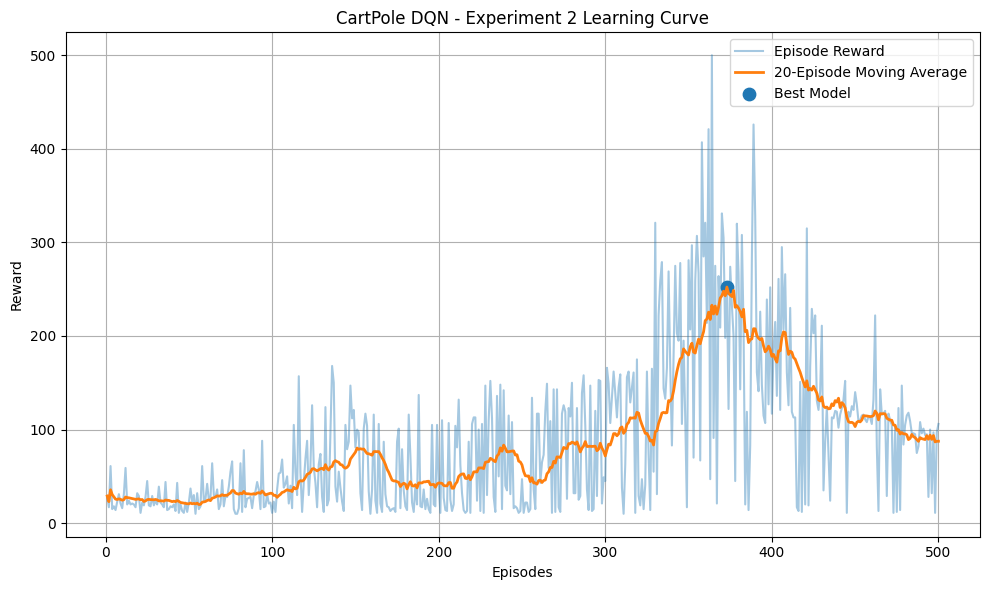

Learning curve saved as: cartpole_dqn_exp2_learning_curve.png


EVALUATING BEST MODEL
Evaluation Episode  1: Reward = 196.0
Evaluation Episode  2: Reward = 174.0
Evaluation Episode  3: Reward = 192.0
Evaluation Episode  4: Reward = 179.0
Evaluation Episode  5: Reward = 190.0
Evaluation Episode  6: Reward = 193.0
Evaluation Episode  7: Reward = 191.0
Evaluation Episode  8: Reward = 189.0
Evaluation Episode  9: Reward = 174.0
Evaluation Episode 10: Reward = 184.0
Evaluation Episode 11: Reward = 177.0
Evaluation Episode 12: Reward = 184.0
Evaluation Episode 13: Reward = 192.0
Evaluation Episode 14: Reward = 179.0
Evaluation Episode 15: Reward = 179.0
Evaluation Episode 16: Reward = 189.0
Evaluation Episode 17: Reward = 180.0
Evaluation Episode 18: Reward = 178.0
Evaluation Episode 19: Reward = 178.0
Evaluation Episode 20: Reward = 179.0


BEST MODEL PERFORMANCE
Best model episode         : 373
Best training moving avg   : 252.30
Evaluation episodes        : 20
Average evaluation reward  :

C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists



Best model demonstration reward: 190.0


EXPERIMENT 2 COMPLETED

Generated files:
1. cartpole_dqn_best_model_exp2.pth
2. cartpole_dqn_final_model_exp2.pth
3. cartpole_dqn_exp2_results.csv
4. cartpole_dqn_exp2_learning_curve.png
5. cartpole_dqn_exp2_evaluation.txt

Use these results for Lab-5 analysis.


In [1]:
# ============================================================
# LAB 5 - EXPERIMENT 2
# CartPole Balancing using DQN
#
# Experiment 2:
# Save and evaluate the BEST model during training
# based on 20-episode moving average reward.
# ============================================================

import os
import random
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym

import torch
import torch.nn as nn
import torch.optim as optim


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 42

NUM_EPISODES = 500

GAMMA = 0.99

LEARNING_RATE = 0.001

BATCH_SIZE = 64

MEMORY_SIZE = 50000

MIN_MEMORY_SIZE = 1000

EPSILON_START = 1.0
EPSILON_MIN = 0.05
EPSILON_DECAY = 0.995

TARGET_UPDATE_FREQUENCY = 10

HIDDEN_SIZE = 128


# ============================================================
# EXPERIMENT 2 FILES
# ============================================================

BEST_MODEL_FILE = "cartpole_dqn_best_model_exp2.pth"

FINAL_MODEL_FILE = "cartpole_dqn_final_model_exp2.pth"

REWARD_CSV = "cartpole_dqn_exp2_results.csv"

LEARNING_CURVE_FILE = "cartpole_dqn_exp2_learning_curve.png"

EVALUATION_FILE = "cartpole_dqn_exp2_evaluation.txt"


# ============================================================
# 2. RANDOM SEED
# ============================================================

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)


# ============================================================
# 3. DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)


# ============================================================
# 4. CREATE ENVIRONMENT
# ============================================================

env = gym.make("CartPole-v1")

env.reset(seed=SEED)

env.action_space.seed(SEED)


state_size = env.observation_space.shape[0]

action_size = env.action_space.n


print("\n")
print("=" * 60)
print("CARTPOLE DQN - EXPERIMENT 2")
print("=" * 60)

print("\nEnvironment:", "CartPole-v1")

print("State size :", state_size)

print("Action size:", action_size)


print("\nState variables:")

print("1. Cart position")
print("2. Cart velocity")
print("3. Pole angle")
print("4. Pole angular velocity")


print("\nActions:")

print("0 = Move Left")

print("1 = Move Right")


# ============================================================
# 5. REPLAY BUFFER
# ============================================================

class ReplayBuffer:

    def __init__(self, capacity):

        self.memory = deque(
            maxlen=capacity
        )


    def store(
        self,
        state,
        action,
        reward,
        next_state,
        done
    ):

        self.memory.append(
            (
                state,
                action,
                reward,
                next_state,
                done
            )
        )


    def sample(self, batch_size):

        batch = random.sample(
            self.memory,
            batch_size
        )

        states, actions, rewards, next_states, dones = zip(
            *batch
        )

        return (
            np.array(
                states,
                dtype=np.float32
            ),

            np.array(
                actions,
                dtype=np.int64
            ),

            np.array(
                rewards,
                dtype=np.float32
            ),

            np.array(
                next_states,
                dtype=np.float32
            ),

            np.array(
                dones,
                dtype=np.float32
            )
        )


    def __len__(self):

        return len(self.memory)


# ============================================================
# 6. DQN NETWORK
# ============================================================

class DQN(nn.Module):

    def __init__(
        self,
        state_size,
        action_size
    ):

        super(DQN, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(
                state_size,
                HIDDEN_SIZE
            ),

            nn.ReLU(),

            nn.Linear(
                HIDDEN_SIZE,
                HIDDEN_SIZE
            ),

            nn.ReLU(),

            nn.Linear(
                HIDDEN_SIZE,
                action_size
            )
        )


    def forward(self, state):

        return self.network(state)


# ============================================================
# 7. CREATE NETWORKS
# ============================================================

policy_network = DQN(
    state_size,
    action_size
).to(device)


target_network = DQN(
    state_size,
    action_size
).to(device)


# Initially same weights

target_network.load_state_dict(
    policy_network.state_dict()
)

target_network.eval()


# ============================================================
# 8. OPTIMIZER AND LOSS
# ============================================================

optimizer = optim.Adam(
    policy_network.parameters(),
    lr=LEARNING_RATE
)


loss_function = nn.SmoothL1Loss()


# ============================================================
# 9. REPLAY MEMORY
# ============================================================

memory = ReplayBuffer(
    MEMORY_SIZE
)


# ============================================================
# 10. EPSILON-GREEDY ACTION
# ============================================================

def select_action(
    state,
    epsilon
):

    # --------------------------------------------------------
    # Exploration
    # --------------------------------------------------------

    if random.random() < epsilon:

        return env.action_space.sample()


    # --------------------------------------------------------
    # Exploitation
    # --------------------------------------------------------

    state_tensor = torch.tensor(
        state,
        dtype=torch.float32
    ).unsqueeze(0).to(device)


    with torch.no_grad():

        q_values = policy_network(
            state_tensor
        )


    action = q_values.argmax(
        dim=1
    ).item()


    return action


# ============================================================
# 11. TRAIN DQN
# ============================================================

def train_dqn():

    if len(memory) < MIN_MEMORY_SIZE:

        return None


    # Sample mini-batch

    states, actions, rewards, next_states, dones = \
        memory.sample(BATCH_SIZE)


    states = torch.tensor(
        states,
        dtype=torch.float32
    ).to(device)


    actions = torch.tensor(
        actions,
        dtype=torch.long
    ).to(device)


    rewards = torch.tensor(
        rewards,
        dtype=torch.float32
    ).to(device)


    next_states = torch.tensor(
        next_states,
        dtype=torch.float32
    ).to(device)


    dones = torch.tensor(
        dones,
        dtype=torch.float32
    ).to(device)


    # --------------------------------------------------------
    # Current Q-value
    # --------------------------------------------------------

    current_q_values = policy_network(
        states
    ).gather(
        1,
        actions.unsqueeze(1)
    ).squeeze(1)


    # --------------------------------------------------------
    # Next Q-value
    # --------------------------------------------------------

    with torch.no_grad():

        next_q_values = target_network(
            next_states
        ).max(
            dim=1
        )[0]


    # --------------------------------------------------------
    # DQN target
    # y = r + gamma * max Q(s',a')
    # --------------------------------------------------------

    target_q_values = rewards + (
        GAMMA *
        next_q_values *
        (1 - dones)
    )


    # --------------------------------------------------------
    # Loss
    # --------------------------------------------------------

    loss = loss_function(
        current_q_values,
        target_q_values
    )


    # --------------------------------------------------------
    # Backpropagation
    # --------------------------------------------------------

    optimizer.zero_grad()

    loss.backward()


    # Gradient clipping

    torch.nn.utils.clip_grad_norm_(
        policy_network.parameters(),
        max_norm=1.0
    )


    optimizer.step()


    return loss.item()


# ============================================================
# 12. TRAINING VARIABLES
# ============================================================

episode_rewards = []

episode_losses = []

epsilon_values = []

moving_averages = []


epsilon = EPSILON_START


# ============================================================
# IMPORTANT FOR EXPERIMENT 2
# ============================================================

best_average_reward = -float("inf")

best_episode = 0

best_training_reward = 0


# ============================================================
# 13. TRAINING LOOP
# ============================================================

print("\n")

print("=" * 60)

print("STARTING EXPERIMENT 2 TRAINING")

print("=" * 60)


for episode in range(
    1,
    NUM_EPISODES + 1
):


    # --------------------------------------------------------
    # Reset environment
    # --------------------------------------------------------

    state, info = env.reset()


    total_reward = 0

    losses = []


    # --------------------------------------------------------
    # Episode
    # --------------------------------------------------------

    while True:


        # Choose action

        action = select_action(
            state,
            epsilon
        )


        # Environment step

        next_state, reward, terminated, truncated, info = \
            env.step(action)


        done = terminated or truncated


        # Store experience

        memory.store(
            state,
            action,
            reward,
            next_state,
            done
        )


        # Train

        loss = train_dqn()


        if loss is not None:

            losses.append(loss)


        # Move to next state

        state = next_state


        total_reward += reward


        if done:

            break


    # --------------------------------------------------------
    # Save episode reward
    # --------------------------------------------------------

    episode_rewards.append(
        total_reward
    )


    # --------------------------------------------------------
    # Save loss
    # --------------------------------------------------------

    if len(losses) > 0:

        episode_losses.append(
            np.mean(losses)
        )

    else:

        episode_losses.append(
            0
        )


    # --------------------------------------------------------
    # Save epsilon
    # --------------------------------------------------------

    epsilon_values.append(
        epsilon
    )


    # --------------------------------------------------------
    # Calculate 20-episode moving average
    # --------------------------------------------------------

    if len(episode_rewards) >= 20:

        average_reward = np.mean(
            episode_rewards[-20:]
        )

    else:

        average_reward = np.mean(
            episode_rewards
        )


    moving_averages.append(
        average_reward
    )


    # ========================================================
    # EXPERIMENT 2:
    # SAVE BEST MODEL
    # ========================================================

    if (
        len(episode_rewards) >= 20
        and average_reward > best_average_reward
    ):

        best_average_reward = average_reward

        best_episode = episode

        best_training_reward = total_reward


        torch.save(
            policy_network.state_dict(),
            BEST_MODEL_FILE
        )


        print(
            "\n*** BEST MODEL SAVED ***"
        )

        print(
            "Episode:",
            episode
        )

        print(
            "20-Episode Average:",
            f"{average_reward:.2f}"
        )

        print(
            "Episode Reward:",
            f"{total_reward:.2f}"
        )

        print(
            "************************\n"
        )


    # --------------------------------------------------------
    # Decrease epsilon
    # --------------------------------------------------------

    epsilon = max(
        EPSILON_MIN,
        epsilon * EPSILON_DECAY
    )


    # --------------------------------------------------------
    # Update target network
    # --------------------------------------------------------

    if episode % TARGET_UPDATE_FREQUENCY == 0:

        target_network.load_state_dict(
            policy_network.state_dict()
        )


    # --------------------------------------------------------
    # Print every 10 episodes
    # --------------------------------------------------------

    if (
        episode % 10 == 0
        or episode == 1
    ):

        print(
            f"Episode: {episode:3d} | "
            f"Reward: {total_reward:6.1f} | "
            f"Avg(20): {average_reward:6.1f} | "
            f"Epsilon: {epsilon:.3f}"
        )


# ============================================================
# 14. SAVE FINAL MODEL
# ============================================================

torch.save(
    policy_network.state_dict(),
    FINAL_MODEL_FILE
)


print("\n")

print(
    "Final model saved as:",
    FINAL_MODEL_FILE
)


print(
    "Best model saved as:",
    BEST_MODEL_FILE
)


# ============================================================
# 15. TRAINING PERFORMANCE
# ============================================================

average_training_reward = np.mean(
    episode_rewards
)


last_20_average = np.mean(
    episode_rewards[-20:]
)


maximum_reward = np.max(
    episode_rewards
)


minimum_reward = np.min(
    episode_rewards
)


best_moving_average = np.max(
    moving_averages
)


# ============================================================
# 16. PRINT TRAINING PERFORMANCE
# ============================================================

print("\n")

print("=" * 60)

print("EXPERIMENT 2 TRAINING PERFORMANCE")

print("=" * 60)


print(
    f"Number of episodes          : "
    f"{NUM_EPISODES}"
)


print(
    f"Average training reward     : "
    f"{average_training_reward:.2f}"
)


print(
    f"Last 20 episode average     : "
    f"{last_20_average:.2f}"
)


print(
    f"Maximum reward              : "
    f"{maximum_reward:.2f}"
)


print(
    f"Minimum reward              : "
    f"{minimum_reward:.2f}"
)


print(
    f"Best moving average         : "
    f"{best_moving_average:.2f}"
)


print(
    f"Best model episode          : "
    f"{best_episode}"
)


# ============================================================
# 17. SAVE TRAINING DATA
# ============================================================

results_df = pd.DataFrame({

    "Episode":
        range(
            1,
            NUM_EPISODES + 1
        ),

    "Reward":
        episode_rewards,

    "Loss":
        episode_losses,

    "Epsilon":
        epsilon_values,

    "Moving_Average_20":
        moving_averages

})


results_df.to_csv(
    REWARD_CSV,
    index=False
)


print(
    "\nTraining data saved as:",
    REWARD_CSV
)


# ============================================================
# 18. LEARNING CURVE
# ============================================================

episodes = np.arange(
    1,
    NUM_EPISODES + 1
)


plt.figure(
    figsize=(10, 6)
)


plt.plot(
    episodes,
    episode_rewards,
    alpha=0.4,
    label="Episode Reward"
)


plt.plot(
    episodes,
    moving_averages,
    linewidth=2,
    label="20-Episode Moving Average"
)


# Mark best model

plt.scatter(
    best_episode,
    best_moving_average,
    s=80,
    label="Best Model"
)


plt.xlabel(
    "Episodes"
)


plt.ylabel(
    "Reward"
)


plt.title(
    "CartPole DQN - Experiment 2 Learning Curve"
)


plt.legend()


plt.grid(
    True
)


plt.tight_layout()


plt.savefig(
    LEARNING_CURVE_FILE,
    dpi=300
)


plt.show()


print(
    "Learning curve saved as:",
    LEARNING_CURVE_FILE
)


# ============================================================
# 19. EVALUATION FUNCTION
# ============================================================

def evaluate_agent(
    model_file,
    num_episodes=20
):


    # --------------------------------------------------------
    # Create a separate evaluation environment
    # --------------------------------------------------------

    evaluation_env = gym.make(
        "CartPole-v1"
    )


    # --------------------------------------------------------
    # Load model
    # --------------------------------------------------------

    evaluation_model = DQN(
        state_size,
        action_size
    ).to(device)


    evaluation_model.load_state_dict(
        torch.load(
            model_file,
            map_location=device
        )
    )


    evaluation_model.eval()


    evaluation_rewards = []


    # --------------------------------------------------------
    # Evaluation episodes
    # --------------------------------------------------------

    for episode in range(
        1,
        num_episodes + 1
    ):


        state, info = evaluation_env.reset()


        total_reward = 0


        while True:


            state_tensor = torch.tensor(
                state,
                dtype=torch.float32
            ).unsqueeze(0).to(device)


            # No exploration

            with torch.no_grad():

                q_values = evaluation_model(
                    state_tensor
                )


            # Always choose best action

            action = q_values.argmax(
                dim=1
            ).item()


            next_state, reward, terminated, truncated, info = \
                evaluation_env.step(action)


            total_reward += reward


            state = next_state


            if (
                terminated
                or truncated
            ):

                break


        evaluation_rewards.append(
            total_reward
        )


        print(
            f"Evaluation Episode "
            f"{episode:2d}: "
            f"Reward = "
            f"{total_reward:.1f}"
        )


    evaluation_env.close()


    return evaluation_rewards


# ============================================================
# 20. EVALUATE BEST MODEL
# ============================================================

print("\n")

print("=" * 60)

print("EVALUATING BEST MODEL")

print("=" * 60)


best_evaluation_rewards = evaluate_agent(
    BEST_MODEL_FILE,
    num_episodes=20
)


# ============================================================
# 21. BEST MODEL PERFORMANCE
# ============================================================

best_eval_average = np.mean(
    best_evaluation_rewards
)


best_eval_max = np.max(
    best_evaluation_rewards
)


best_eval_min = np.min(
    best_evaluation_rewards
)


# ============================================================
# 22. SUCCESS RATE
# ============================================================

SUCCESS_THRESHOLD = 195


successful_episodes = sum(
    reward >= SUCCESS_THRESHOLD
    for reward in best_evaluation_rewards
)


success_rate = (
    successful_episodes
    /
    len(best_evaluation_rewards)
) * 100


# ============================================================
# 23. PRINT BEST MODEL RESULTS
# ============================================================

print("\n")

print("=" * 60)

print("BEST MODEL PERFORMANCE")

print("=" * 60)


print(
    f"Best model episode         : "
    f"{best_episode}"
)


print(
    f"Best training moving avg   : "
    f"{best_moving_average:.2f}"
)


print(
    f"Evaluation episodes        : "
    f"{len(best_evaluation_rewards)}"
)


print(
    f"Average evaluation reward  : "
    f"{best_eval_average:.2f}"
)


print(
    f"Maximum evaluation reward  : "
    f"{best_eval_max:.2f}"
)


print(
    f"Minimum evaluation reward  : "
    f"{best_eval_min:.2f}"
)


print(
    f"Successful episodes        : "
    f"{successful_episodes}/"
    f"{len(best_evaluation_rewards)}"
)


print(
    f"Success rate               : "
    f"{success_rate:.2f}%"
)


print(
    f"Success threshold          : "
    f"{SUCCESS_THRESHOLD}"
)


# ============================================================
# 24. EVALUATE FINAL MODEL TOO
# ============================================================

print("\n")

print("=" * 60)

print("EVALUATING FINAL MODEL")

print("=" * 60)


final_evaluation_rewards = evaluate_agent(
    FINAL_MODEL_FILE,
    num_episodes=20
)


final_eval_average = np.mean(
    final_evaluation_rewards
)


final_eval_max = np.max(
    final_evaluation_rewards
)


final_eval_min = np.min(
    final_evaluation_rewards
)


final_successful_episodes = sum(
    reward >= SUCCESS_THRESHOLD
    for reward in final_evaluation_rewards
)


final_success_rate = (
    final_successful_episodes
    /
    len(final_evaluation_rewards)
) * 100


# ============================================================
# 25. COMPARISON
# ============================================================

print("\n")

print("=" * 60)

print("BEST MODEL vs FINAL MODEL")

print("=" * 60)


print(
    f"{'Measure':<30}"
    f"{'Best Model':>15}"
    f"{'Final Model':>15}"
)


print("-" * 60)


print(
    f"{'Evaluation Average':<30}"
    f"{best_eval_average:>15.2f}"
    f"{final_eval_average:>15.2f}"
)


print(
    f"{'Maximum Evaluation Reward':<30}"
    f"{best_eval_max:>15.2f}"
    f"{final_eval_max:>15.2f}"
)


print(
    f"{'Minimum Evaluation Reward':<30}"
    f"{best_eval_min:>15.2f}"
    f"{final_eval_min:>15.2f}"
)


print(
    f"{'Success Rate (%)':<30}"
    f"{success_rate:>15.2f}"
    f"{final_success_rate:>15.2f}"
)


# ============================================================
# 26. SAVE EVALUATION RESULTS
# ============================================================

with open(
    EVALUATION_FILE,
    "w"
) as file:


    file.write(
        "CartPole DQN - Experiment 2\n"
    )

    file.write(
        "===========================\n\n"
    )


    file.write(
        "TRAINING RESULTS\n"
    )

    file.write(
        "----------------\n"
    )


    file.write(
        f"Training episodes: "
        f"{NUM_EPISODES}\n"
    )


    file.write(
        f"Average training reward: "
        f"{average_training_reward:.2f}\n"
    )


    file.write(
        f"Last 20 episode average: "
        f"{last_20_average:.2f}\n"
    )


    file.write(
        f"Maximum reward: "
        f"{maximum_reward:.2f}\n"
    )


    file.write(
        f"Minimum reward: "
        f"{minimum_reward:.2f}\n"
    )


    file.write(
        f"Best moving average: "
        f"{best_moving_average:.2f}\n"
    )


    file.write(
        f"Best model episode: "
        f"{best_episode}\n\n"
    )


    file.write(
        "BEST MODEL EVALUATION\n"
    )

    file.write(
        "---------------------\n"
    )


    file.write(
        f"Average reward: "
        f"{best_eval_average:.2f}\n"
    )


    file.write(
        f"Maximum reward: "
        f"{best_eval_max:.2f}\n"
    )


    file.write(
        f"Minimum reward: "
        f"{best_eval_min:.2f}\n"
    )


    file.write(
        f"Successful episodes: "
        f"{successful_episodes}/20\n"
    )


    file.write(
        f"Success rate: "
        f"{success_rate:.2f}%\n\n"
    )


    file.write(
        "FINAL MODEL EVALUATION\n"
    )

    file.write(
        "----------------------\n"
    )


    file.write(
        f"Average reward: "
        f"{final_eval_average:.2f}\n"
    )


    file.write(
        f"Maximum reward: "
        f"{final_eval_max:.2f}\n"
    )


    file.write(
        f"Minimum reward: "
        f"{final_eval_min:.2f}\n"
    )


    file.write(
        f"Successful episodes: "
        f"{final_successful_episodes}/20\n"
    )


    file.write(
        f"Success rate: "
        f"{final_success_rate:.2f}%\n\n"
    )


    file.write(
        "COMPARISON\n"
    )

    file.write(
        "----------\n"
    )


    file.write(
        f"Best model average: "
        f"{best_eval_average:.2f}\n"
    )


    file.write(
        f"Final model average: "
        f"{final_eval_average:.2f}\n"
    )


print(
    "\nEvaluation results saved as:",
    EVALUATION_FILE
)


# ============================================================
# 27. FINAL VISUAL DEMONSTRATION
#     USING BEST MODEL
# ============================================================

print("\n")

print("=" * 60)

print("RUNNING BEST MODEL DEMONSTRATION")

print("=" * 60)


demo_env = gym.make(
    "CartPole-v1",
    render_mode="human"
)


demo_model = DQN(
    state_size,
    action_size
).to(device)


demo_model.load_state_dict(
    torch.load(
        BEST_MODEL_FILE,
        map_location=device
    )
)


demo_model.eval()


state, info = demo_env.reset()


demo_reward = 0


while True:


    state_tensor = torch.tensor(
        state,
        dtype=torch.float32
    ).unsqueeze(0).to(device)


    with torch.no_grad():

        q_values = demo_model(
            state_tensor
        )


    action = q_values.argmax(
        dim=1
    ).item()


    next_state, reward, terminated, truncated, info = \
        demo_env.step(action)


    demo_reward += reward


    state = next_state


    if (
        terminated
        or truncated
    ):

        break


demo_env.close()


print(
    "\nBest model demonstration reward:",
    demo_reward
)


# ============================================================
# 28. COMPLETION
# ============================================================

print("\n")

print("=" * 60)

print("EXPERIMENT 2 COMPLETED")

print("=" * 60)


print("\nGenerated files:")

print(
    "1.",
    BEST_MODEL_FILE
)

print(
    "2.",
    FINAL_MODEL_FILE
)

print(
    "3.",
    REWARD_CSV
)

print(
    "4.",
    LEARNING_CURVE_FILE
)

print(
    "5.",
    EVALUATION_FILE
)

print("\nUse these results for Lab-5 analysis.")